In [1]:
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from sklearn.linear_model import LinearRegression

df = px.data.tips()
X = df.total_bill.values.reshape(-1, 1)

model = LinearRegression()
model.fit(X, df.tip)

x_range = np.linspace(X.min(), X.max(), 100)
y_range = model.predict(x_range.reshape(-1, 1))

fig = px.scatter(df, x='total_bill', y='tip', opacity=0.65)
fig.add_traces(go.Scatter(x=x_range, y=y_range, name='Regression Fit'))
fig.show()

In [2]:
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from sklearn.ensemble import RandomForestRegressor

# Load the dataset
df = px.data.tips()
X = df.total_bill.values.reshape(-1, 1)
y = df.tip

# Train the Random Forest model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

# Generate predictions
x_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_range = model.predict(x_range)

# Create the scatter plot
fig = px.scatter(df, x='total_bill', y='tip', opacity=0.65)

# Add the Random Forest regression line
fig.add_traces(go.Scatter(x=x_range.flatten(), y=y_range, name='Random Forest Fit', mode='lines'))

# Show the plot
fig.show()

In [8]:
import os
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import export_graphviz
import pydot

# Set the path to the Graphviz bin directory
os.environ["PATH"] += os.pathsep + 'C:/Program Files/Graphviz/bin/'

# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Train a Random Forest classifier
rf_classifier = RandomForestClassifier(n_estimators=10, random_state=42)
rf_classifier.fit(X, y)

# Extract an individual decision tree from the Random Forest
individual_tree = rf_classifier.estimators_[0]  # Get the first tree (you can choose any index)

# Export the decision tree as a DOT file
export_graphviz(individual_tree, out_file='individual_tree.dot',
                feature_names=iris.feature_names,
                class_names=iris.target_names,
                rounded=True, filled=True)

# Convert the DOT file to a PNG image using Graphviz
(graph,) = pydot.graph_from_dot_file('individual_tree.dot')
# graph = pydot.graph_from_dot_file('individual_tree.dot')

# Write the PNG image
graph.write_png('individual_tree.png')


FileNotFoundError: [WinError 2] "dot" not found in path.

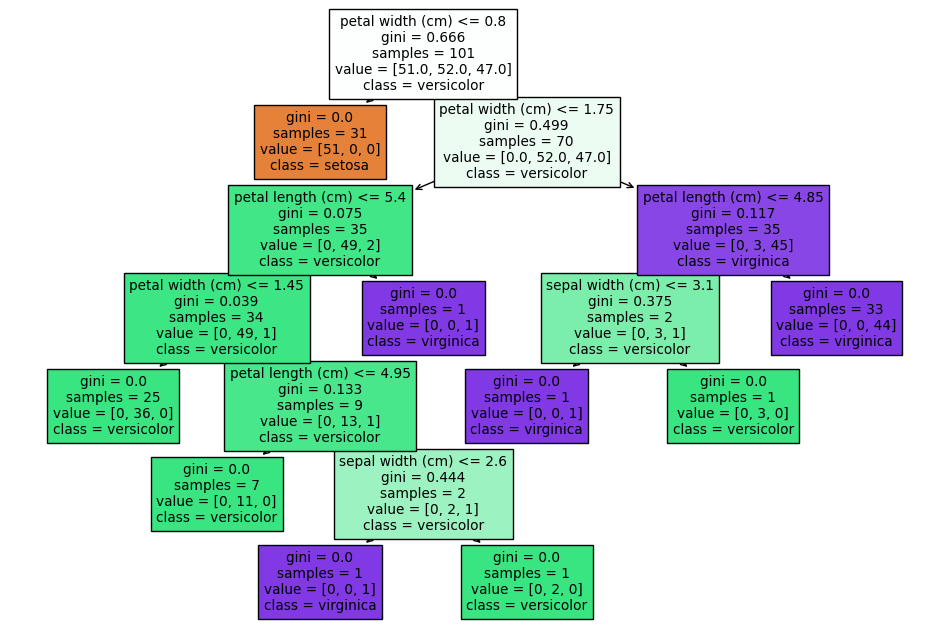

In [6]:
                   
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree

# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Train a Random Forest classifier
rf_classifier = RandomForestClassifier(n_estimators=10, random_state=42)
rf_classifier.fit(X, y)

# Extract an individual decision tree from the Random Forest
individual_tree = rf_classifier.estimators_[0]  # Get the first tree (you can choose any index)

# Visualize the decision tree using Matplotlib's plot_tree method
plt.figure(figsize=(12, 8))
plot_tree(individual_tree, feature_names=iris.feature_names, class_names=iris.target_names, filled=True)
plt.show()


In [9]:
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.datasets import make_classification
from sklearn.linear_model import LinearRegression

# Generate synthetic classification data (15 features, 1000 samples)
X, y = make_classification(n_samples=1000, n_features=15, n_informative=5, random_state=42)

# Train Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X, y)

# Identify the top-performing feature
feature_importances = rf_classifier.feature_importances_
top_feature_index = np.argmax(feature_importances)  # Get index of most important feature
top_feature_values = X[:, top_feature_index]  # Extract that feature

# Get probability predictions for class 'a' (assuming 'a' corresponds to class 1)
prob_a = rf_classifier.predict_proba(X)[:, 1]

# --- Train Regression Models ---
# 1. Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(top_feature_values.reshape(-1, 1), prob_a)
lin_reg_pred = lin_reg.predict(top_feature_values.reshape(-1, 1))

# 2. Random Forest Regression
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)
rf_regressor.fit(top_feature_values.reshape(-1, 1), prob_a)
rf_reg_pred = rf_regressor.predict(top_feature_values.reshape(-1, 1))

# --- Create Plotly Figure ---
fig = px.scatter(
    x=top_feature_values, 
    y=prob_a, 
    labels={'x': f"Top Feature (Index {top_feature_index})", 'y': "Predicted Probability of Class 'a'"},
    title="Probability Predictions vs. Top Feature",
    opacity=0.5
)

# Add Linear Regression Line
fig.add_trace(go.Scatter(
    x=top_feature_values, 
    y=lin_reg_pred, 
    mode='lines', 
    name="Linear Regression",
    line=dict(color='red', dash='dash')
))

# Add Random Forest Regression Line
fig.add_trace(go.Scatter(
    x=top_feature_values, 
    y=rf_reg_pred, 
    mode='lines', 
    name="Random Forest Regression",
    line=dict(color='green')
))

# Show the plot
fig.show()


In [12]:
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.datasets import make_classification
from sklearn.linear_model import LinearRegression

# Generate synthetic classification data (15 features, 1000 samples)
X, y = make_classification(n_samples=100, n_features=15, n_informative=5, random_state=42)

# Train Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X, y)

# Identify the top-performing feature
feature_importances = rf_classifier.feature_importances_
top_feature_index = np.argmax(feature_importances)  # Get index of most important feature
top_feature_values = X[:, top_feature_index]  # Extract that feature

# Get probability predictions for class 'a' (assuming 'a' corresponds to class 1)
prob_a = rf_classifier.predict_proba(X)[:, 1]

# Sort the data points by the top feature values
sorted_indices = np.argsort(top_feature_values)
top_feature_values_sorted = top_feature_values[sorted_indices]
prob_a_sorted = prob_a[sorted_indices]

# --- Train Regression Models ---
# 1. Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(top_feature_values_sorted.reshape(-1, 1), prob_a_sorted)
lin_reg_pred = lin_reg.predict(top_feature_values_sorted.reshape(-1, 1))

# 2. Random Forest Regression
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)
rf_regressor.fit(top_feature_values_sorted.reshape(-1, 1), prob_a_sorted)
rf_reg_pred = rf_regressor.predict(top_feature_values_sorted.reshape(-1, 1))

# --- Create Plotly Figure ---
fig = px.scatter(
    x=top_feature_values_sorted, 
    y=prob_a_sorted, 
    labels={'x': f"Top Feature (Index {top_feature_index})", 'y': "Predicted Probability of Class 'a'"},
    title="Probability Predictions vs. Top Feature",
    opacity=0.5
)

# Add Linear Regression Line
fig.add_trace(go.Scatter(
    x=top_feature_values_sorted, 
    y=lin_reg_pred, 
    mode='lines', 
    name="Linear Regression",
    line=dict(color='red', dash='dash')
))

# Add Random Forest Regression Line
fig.add_trace(go.Scatter(
    x=top_feature_values_sorted, 
    y=rf_reg_pred, 
    mode='lines', 
    name="Random Forest Regression",
    line=dict(color='green')
))

# Show the plot
fig.show()

In [ ]:
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LinearRegression

# Create a dummy DataFrame
np.random.seed(42)
n_samples = 1000
n_features = 15

# Generate random features
X_dummy = np.random.rand(n_samples, n_features)
y_dummy = np.random.choice([0, 1], size=n_samples)

# Convert to DataFrame
df_dummy = pd.DataFrame(X_dummy, columns=[f'feature_{i}' for i in range(n_features)])
df_dummy['target'] = y_dummy

# Extract features and target from DataFrame
X = df_dummy.drop(columns=['target']).values
y = df_dummy['target'].values

# Train Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X, y)

# Identify the top-performing feature
feature_importances = rf_classifier.feature_importances_
top_feature_index = np.argmax(feature_importances)  # Get index of most important feature
top_feature_values = X[:, top_feature_index]  # Extract that feature

# Get probability predictions for class 'a' (assuming 'a' corresponds to class 1)
prob_a = rf_classifier.predict_proba(X)[:, 1]

# Sort the data points by the top feature values
sorted_indices = np.argsort(top_feature_values)
top_feature_values_sorted = top_feature_values[sorted_indices]
prob_a_sorted = prob_a[sorted_indices]

# --- Train Regression Models ---
# 1. Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(top_feature_values_sorted.reshape(-1, 1), prob_a_sorted)
lin_reg_pred = lin_reg.predict(top_feature_values_sorted.reshape(-1, 1))

# 2. Random Forest Regression
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)
rf_regressor.fit(top_feature_values_sorted.reshape(-1, 1), prob_a_sorted)
rf_reg_pred = rf_regressor.predict(top_feature_values_sorted.reshape(-1, 1))

# --- Create Plotly Figure ---
fig = px.scatter(
    x=top_feature_values_sorted, 
    y=prob_a_sorted, 
    labels={'x': f"Top Feature (Index {top_feature_index})", 'y': "Predicted Probability of Class 'a'"},
    title="Probability Predictions vs. Top Feature",
    opacity=0.5
)

# Add Linear Regression Line
fig.add_trace(go.Scatter(
    x=top_feature_values_sorted, 
    y=lin_reg_pred, 
    mode='lines', 
    name="Linear Regression",
    line=dict(color='red', dash='dash')
))

# Add Random Forest Regression Line
fig.add_trace(go.Scatter(
    x=top_feature_values_sorted, 
    y=rf_reg_pred, 
    mode='lines', 
    name="Random Forest Regression",
    line=dict(color='green')
))

# Show the plot
fig.show()